[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/19UA8SJ_k-TJhx7k_Y_lsd5TGCtUBUwrc)

# Overview

The Naive Bayes classifier, a simple probabilistic classifier based on the popular Bayes’ probability theorem, is known for creating simple yet well performing models, especially in the fields of document classification.

## Good baseline

Even though it is often outperformed by other techniques such as Boosted trees, Random forests, SVMs etc, Naive Bayes classifier is very efficient since it is less computationally intensive (in both CPU and memory) and it requires a small amount of training data. Moreover, the training time with Naive Bayes is significantly smaller as opposed to alternative methods.

It is almost always a good baseline to start with when dealing with any kind of Text Classification.


---


Here, we will use a Naive Bayes model to classify Restaurant reviews (positive or negative).

**Dataset**: https://www.dropbox.com/s/bf8v1sx9st8v01y/Restaurant_Reviews.tsv?raw=1




In [0]:
import pandas as pd
import numpy as np

df = pd.read_table('https://www.dropbox.com/s/bf8v1sx9st8v01y/Restaurant_Reviews.tsv?raw=1')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


## Data prep

In [0]:
print(df.shape)

(1000, 2)


In [0]:
print(df.isnull().sum())

Review    0
Liked     0
dtype: int64


In [0]:
print(df['Liked'].unique())

[1 0]


In [0]:
df.describe()

,Liked
count,1000.00000
mean,0.50000
std,0.50025
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


**Observation:** doesn't look like any missing data

## Using NLTK

In [0]:
import nltk
nltk.download('all')

In [0]:
import string
def remove_punctuation(str):
  return str.translate(str.maketrans("", "", string.punctuation))

In [0]:
from nltk import pos_tag
import nltk.corpus.reader.wordnet as wordnet

def pos_for_WordNetLemmatizer(token):  
  word, tag = pos_tag([token])[0]
  
  if tag in ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ']:
    return wordnet.VERB
  elif tag in ['JJ', 'JJR', 'JJS']:
    return wordnet.ADJ
  elif tag in ['RB', 'RBR', 'RBS']:
    return wordnet.ADV
  
  return wordnet.NOUN

In [0]:
from enum import Enum
class Wordbase(Enum):
  LEMMA = 0
  STEM = 1
  TEXT = 2

In [0]:
from nltk import word_tokenize
from nltk import WordNetLemmatizer
from nltk import PorterStemmer

def process_and_tokenize(str, word_base):
  stopwords = nltk.corpus.stopwords.words('english')
  lemmatizer = WordNetLemmatizer()
  stemmer = PorterStemmer()
  
  tokens = []
  for t in word_tokenize(str):
    updated_t = remove_punctuation(t)
    if len(updated_t) > 0 and t.lower() not in stopwords:
      if (word_base == Wordbase.LEMMA):
        tokens.append(lemmatizer.lemmatize(updated_t, pos_for_WordNetLemmatizer(updated_t)))
      else:
        tokens.append(stemmer.stem(updated_t))
  
  return ' '.join(tokens)

In [0]:
df['Processed Review'] = df['Review'].apply(lambda str: process_and_tokenize(str, Wordbase.LEMMA))
df.head()

,Review,Liked,Processed Review
0,Wow... Loved this place.,1,Wow Loved place
1,Crust is not good.,0,Crust good
2,Not tasty and the texture was just nasty.,0,tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,Stopped late May bank holiday Rick Steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great price


In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_df=0.5, min_df=2)
X = tfidf_vectorizer.fit_transform(df['Processed Review']).toarray()
print(tfidf_vectorizer.vocabulary_)

{'wow': 693, 'loved': 365, 'place': 463, 'crust': 148, 'good': 270, 'tasty': 614, 'texture': 620, 'nasty': 407, 'stopped': 592, 'late': 342, 'may': 378, 'recommendation': 510, 'love': 364, 'selection': 542, 'menu': 387, 'great': 272, 'price': 480, 'get': 265, 'want': 669, 'damn': 153, 'pho': 457, 'nt': 419, 'taste': 612, 'fresh': 255, 'potato': 476, 'like': 351, 'could': 139, 'tell': 616, 'make': 371, 'time': 630, 'kept': 334, 'fry': 260, 'touch': 639, 'service': 547, 'would': 692, 'go': 268, 'back': 44, 'cashier': 103, 'care': 102, 'ever': 214, 'say': 534, 'still': 588, 'end': 205, 'overprice': 436, 'try': 644, 'chicken': 114, 'mmmm': 395, 'disgust': 180, 'pretty': 479, 'sure': 603, 'human': 313, 'hair': 283, 'sign': 555, 'highly': 300, 'recommend': 509, 'waitress': 666, 'little': 354, 'slow': 564, 'worth': 691, 'let': 348, 'vegas': 656, 'food': 253, 'amaze': 16, 'also': 13, 'cute': 152, 'beautiful': 58, 'right': 518, 'the': 622, 'red': 511, 'cake': 99, 'stuff': 594, 'never': 411, 'br

In [0]:
vectorized_df = pd.DataFrame(X)
vectorized_df.columns = tfidf_vectorizer.get_feature_names()
print(vectorized_df.shape)
vectorized_df.head()

(1000, 700)


,10,100,12,20,30,35,40,absolutely,acknowledge,actually,...,worst,worth,would,wow,wrap,wrong,year,yet,yummy,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.677896,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


### Classification using Naive Bayes

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, df['Liked'], test_size=0.3, random_state=42)

In [0]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
y_pred = model.fit(X_train, y_train).predict(X_test)
error = y_pred-y_test
print("Number of misclassifications: %d (out of %d)" % (sum(error!=0), len(error)))
print("Error: ", sum(error!=0)/len(error))

Number of misclassifications: 71 (out of 300)
Error:  0.23666666666666666


In [0]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[116  36]
 [ 35 113]]


In [0]:
import matplotlib.pyplot as plt
plt.style.use('classic')
import itertools

def plot_confusion_matrix(cm, classes, cmap=plt.cm.Blues):
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks)
  plt.yticks(tick_marks)
  fmt = 'd'
  thresh = cm.max()/2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt), 
             horizontalalignment="center", 
             color="white" if cm[i, j] > thresh else "black")
  plt.tight_layout()
  plt.title("Confusion Matrix")
  plt.xlabel("Predicted Label")
  plt.ylabel("Actual Label")  
  plt.show()

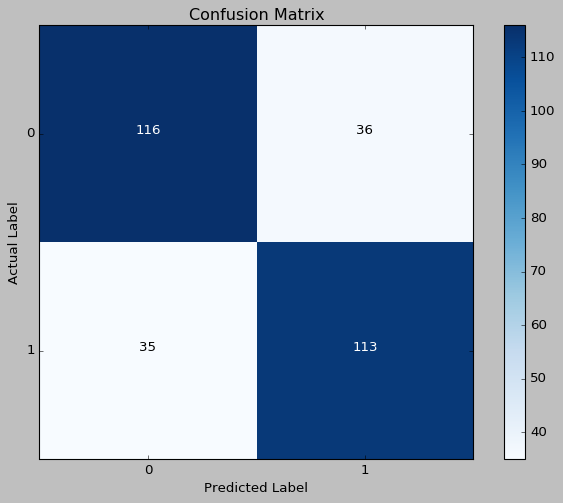

In [0]:
plot_confusion_matrix(conf_matrix, df['Liked'].unique())

## Using `stem` instead of `lemma`

In [0]:
df = pd.read_table('https://www.dropbox.com/s/bf8v1sx9st8v01y/Restaurant_Reviews.tsv?raw=1')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [0]:
df['Processed Review'] = df['Review'].apply(lambda str: process_and_tokenize(str, Wordbase.STEM))
df.head()

,Review,Liked,Processed Review
0,Wow... Loved this place.,1,wow love place
1,Crust is not good.,0,crust good
2,Not tasty and the texture was just nasty.,0,tasti textur nasti
3,Stopped by during the late May bank holiday of...,1,stop late may bank holiday rick steve recommen...
4,The selection on the menu was great and so wer...,1,select menu great price


In [0]:
from IPython import display

def classify_and_plot_confusion_matrix(x_data, y_data, vectorizer=TfidfVectorizer(max_df=0.5, min_df=2)):
  X = vectorizer.fit_transform(x_data).toarray()
  print(vectorizer.vocabulary_)
  
  vectorized_df = pd.DataFrame(X)
  vectorized_df.columns = vectorizer.get_feature_names()
  print(vectorized_df.shape)
  display.display(vectorized_df.head())
  
  print()
  print("Training starts...")
  X_train, X_test, y_train, y_test = train_test_split(X, y_data, test_size=0.3, random_state=42)
  model = MultinomialNB()
  y_pred = model.fit(X_train, y_train).predict(X_test)
  error = y_pred-y_test
  print("Training ends...")
  print("Number of misclassifications: %d (out of %d)" % (sum(error!=0), len(error)))
  print("Error: ", sum(error!=0)/len(error))
  print()
  
  conf_matrix = confusion_matrix(y_test, y_pred)
  print("Confusion Matrix:")
  print(conf_matrix)
  print()
  
  plot_confusion_matrix(conf_matrix, y_data.unique())

{'wow': 694, 'love': 368, 'place': 464, 'crust': 150, 'good': 273, 'tasti': 613, 'textur': 619, 'nasti': 409, 'stop': 588, 'late': 346, 'may': 380, 'recommend': 504, 'select': 540, 'menu': 389, 'great': 276, 'price': 480, 'get': 266, 'want': 669, 'damn': 155, 'pho': 458, 'nt': 422, 'tast': 611, 'fresh': 255, 'potato': 476, 'like': 355, 'could': 141, 'tell': 615, 'made': 372, 'time': 629, 'kept': 337, 'fri': 256, 'touch': 638, 'servic': 544, 'would': 693, 'go': 270, 'back': 45, 'cashier': 106, 'care': 105, 'ever': 213, 'say': 531, 'still': 585, 'end': 204, 'overpr': 438, 'tri': 642, 'chicken': 116, 'mmmm': 397, 'disgust': 178, 'pretti': 479, 'sure': 600, 'human': 316, 'hair': 287, 'sign': 552, 'highli': 302, 'waitress': 666, 'littl': 358, 'slow': 561, 'worth': 692, 'let': 352, 'vega': 657, 'food': 253, 'amaz': 16, 'also': 13, 'cute': 154, 'beauti': 59, 'right': 514, 'the': 621, 'red': 505, 'cake': 100, 'stuff': 591, 'never': 413, 'brought': 90, 'salad': 522, 'ask': 30, 'wall': 668, 'mex

,10,100,12,20,30,35,40,absolut,acknowledg,actual,...,worst,worth,would,wow,wrap,wrong,year,yet,yummi,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.768148,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0



Training starts...
Training ends...
Number of misclassifications: 70 (out of 300)
Error:  0.23333333333333334

Confusion Matrix:
[[117  35]
 [ 35 113]]



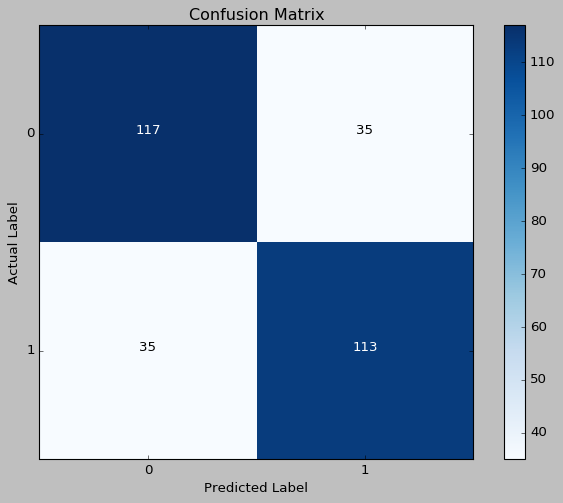

In [0]:
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'])

**Observation:** Stemming seems to be working a bit better than Lemmatization

## Improve stop words list

In [0]:
STOP_WORDS_EXLUSION = set(["no", "nor", "not", "don", "don't", "ain", "aren", "aren't", 
                       "couldn", "couldn't", "didn", "didn't", "doesn", "doesn't", 
                       "hadn", "hadn't", "hasn", "hasn't", "haven", "haven't", 
                       "isn", "isn't", "needn", "needn't", "shouldn", "shouldn't", 
                       "wasn", "wasn't", "weren", "weren't", "won", "won't", 
                       "wouldn", "wouldn't"])

def stop_word_list():
  en_stopwords = nltk.corpus.stopwords.words('english')  
  return [stop for stop in en_stopwords if stop not in STOP_WORDS_EXLUSION]

In [0]:
def process_and_tokenize(str, word_base):
  stopwords = stop_word_list()
  lemmatizer = WordNetLemmatizer()
  stemmer = PorterStemmer()
  
  tokens = []
  for t in word_tokenize(str):
    updated_t = remove_punctuation(t)
    if len(updated_t)>0 and t.lower() not in stopwords:
      if (word_base==Wordbase.LEMMA):
        tokens.append(lemmatizer.lemmatize(updated_t, pos_for_WordNetLemmatizer(updated_t)))
      else:
        tokens.append(stemmer.stem(updated_t))
  
  return ' '.join(tokens)

In [0]:
df['Processed Review'] = df['Review'].apply(lambda str: process_and_tokenize(str, Wordbase.LEMMA))
df.head()

,Review,Liked,Processed Review
0,Wow... Loved this place.,1,Wow Loved place
1,Crust is not good.,0,Crust not good
2,Not tasty and the texture was just nasty.,0,Not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,Stopped late May bank holiday Rick Steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great price


{'wow': 695, 'loved': 365, 'place': 465, 'crust': 148, 'not': 418, 'good': 270, 'tasty': 616, 'texture': 622, 'nasty': 407, 'stopped': 594, 'late': 342, 'may': 378, 'recommendation': 512, 'love': 364, 'selection': 544, 'menu': 387, 'great': 272, 'price': 482, 'get': 265, 'want': 671, 'damn': 153, 'pho': 459, 'nt': 421, 'taste': 614, 'fresh': 255, 'potato': 478, 'like': 351, 'could': 139, 'tell': 618, 'make': 371, 'time': 632, 'kept': 334, 'fry': 260, 'touch': 641, 'service': 549, 'would': 694, 'go': 268, 'back': 44, 'cashier': 103, 'no': 416, 'care': 102, 'ever': 214, 'say': 536, 'still': 590, 'end': 205, 'overprice': 438, 'try': 646, 'chicken': 114, 'mmmm': 395, 'disgust': 180, 'pretty': 481, 'sure': 605, 'human': 313, 'hair': 283, 'sign': 557, 'highly': 300, 'recommend': 511, 'waitress': 668, 'little': 354, 'slow': 566, 'worth': 693, 'let': 348, 'vegas': 658, 'food': 253, 'amaze': 16, 'also': 13, 'cute': 152, 'beautiful': 58, 'right': 520, 'the': 624, 'red': 513, 'cake': 99, 'stuff':

,10,100,12,20,30,35,40,absolutely,acknowledge,actually,...,worst,worth,would,wow,wrap,wrong,year,yet,yummy,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.677896,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0



Training starts...
Training ends...
Number of misclassifications: 61 (out of 300)
Error:  0.20333333333333334

Confusion Matrix:
[[124  28]
 [ 33 115]]



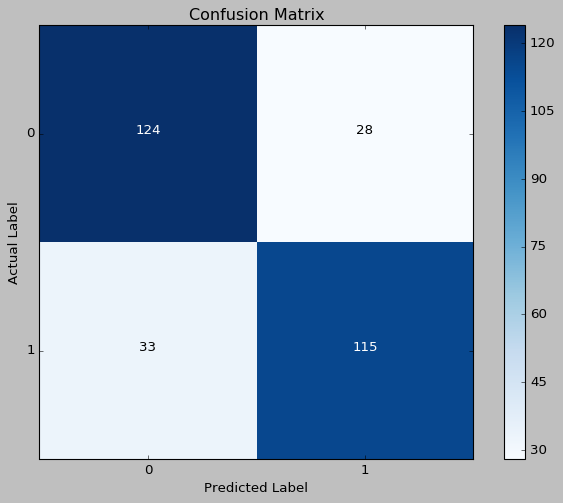

In [0]:
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'])

## Use Spacy

In [0]:
!pip install -U spacy

In [0]:
!python -m spacy download en

In [0]:
df = pd.read_table('https://www.dropbox.com/s/bf8v1sx9st8v01y/Restaurant_Reviews.tsv?raw=1')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [0]:
import spacy
nlp = spacy.load('en')

def process_and_tokenize(str, word_base):
  tokens = []
  whitepaces = []
  doc = nlp(str)
  for t in doc:
    if not (t.is_stop and t.text not in STOP_WORDS_EXLUSION) and not t.is_punct:
      tokens.append(t.text if word_base==Wordbase.TEXT else t.lemma_)
      whitepaces.append(t.whitespace_ if len(t.whitespace_) > 0 else ' ')
  
  ret = tokens[0]
  for i in range(1, len(tokens)):
    ret = whitepaces[i - 1].join((ret, tokens[i]))
  
  return ret

In [0]:
df['Processed Review'] = df['Review'].apply(lambda str: process_and_tokenize(str, Wordbase.LEMMA))
df.head()

,Review,Liked,Processed Review
0,Wow... Loved this place.,1,wow love place
1,Crust is not good.,0,crust not good
2,Not tasty and the texture was just nasty.,0,not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,stop late may bank holiday rick steve recommen...
4,The selection on the menu was great and so wer...,1,the selection menu great price


{'wow': 662, 'love': 353, 'place': 449, 'crust': 146, 'not': 402, 'good': 259, 'tasty': 589, 'texture': 594, 'nasty': 392, 'stop': 566, 'late': 335, 'recommendation': 492, 'the': 597, 'selection': 523, 'menu': 373, 'great': 261, 'price': 465, 'now': 404, 'pron': 470, 'get': 254, 'want': 641, 'damn': 151, 'pho': 443, 'taste': 587, 'that': 596, 'fresh': 246, 'potato': 461, 'like': 342, 'tell': 591, 'time': 606, 'keep': 328, 'warm': 642, 'fry': 250, 'touch': 614, 'service': 527, 'would': 661, 'cashier': 103, 'no': 400, 'care': 102, 'end': 198, 'overprice': 422, 'try': 618, 'chicken': 113, 'mmmm': 381, 'disgust': 178, 'pretty': 464, 'sure': 577, 'human': 304, 'hair': 272, 'sign': 534, 'highly': 289, 'recommend': 491, 'waitress': 638, 'little': 345, 'slow': 541, 'this': 604, 'worth': 660, 'let': 339, 'vegas': 627, 'food': 244, 'amazing': 16, 'cute': 150, 'beautiful': 57, 'so': 544, 'be': 54, 'right': 501, 'red': 493, 'cake': 100, 'stuff': 569, 'bring': 86, 'salad': 508, 'ask': 27, 'wall': 6

,10,100,12,20,30,35,40,absolutely,acknowledge,actually,...,worker,world,worth,would,wow,wrap,wrong,year,yummy,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.765314,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0



Training starts...
Training ends...
Number of misclassifications: 63 (out of 300)
Error:  0.21

Confusion Matrix:
[[125  27]
 [ 36 112]]



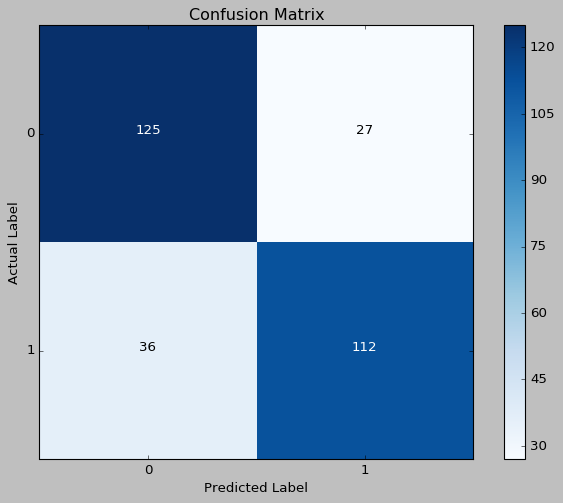

In [0]:
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'])

## Try without lemmatization

In [0]:
df['Processed Review'] = df['Review'].apply(lambda str: process_and_tokenize(str, Wordbase.TEXT))
df.head()

,Review,Liked,Processed Review
0,Wow... Loved this place.,1,Wow Loved place
1,Crust is not good.,0,Crust not good
2,Not tasty and the texture was just nasty.,0,Not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,Stopped late May bank holiday Rick Steve recom...
4,The selection on the menu was great and so wer...,1,The selection menu great prices


{'wow': 729, 'loved': 380, 'place': 480, 'crust': 144, 'not': 430, 'good': 275, 'tasty': 638, 'texture': 643, 'nasty': 417, 'stopped': 612, 'late': 355, 'recommendation': 524, 'the': 646, 'selection': 561, 'menu': 400, 'great': 278, 'prices': 501, 'now': 432, 'getting': 268, 'want': 701, 'damn': 149, 'pho': 474, 'taste': 635, 'that': 645, 'fresh': 256, 'potatoes': 495, 'like': 362, 'tell': 640, 'time': 659, 'kept': 345, 'fries': 261, 'touch': 670, 'service': 569, 'would': 728, 'cashier': 105, 'no': 428, 'care': 104, 'ended': 203, 'overpriced': 454, 'tried': 674, 'chicken': 115, 'mmmm': 407, 'pretty': 498, 'sure': 625, 'human': 323, 'hair': 290, 'highly': 307, 'recommended': 525, 'waitress': 698, 'little': 366, 'slow': 584, 'this': 656, 'worth': 727, 'let': 360, 'vegas': 687, 'food': 253, 'amazing': 16, 'cute': 148, 'beautiful': 60, 'so': 586, 'right': 535, 'red': 526, 'stuff': 614, 'they': 651, 'brought': 88, 'salad': 544, 'asked': 28, 'wall': 700, 'mexican': 401, 'tacos': 631, 'friend

,10,100,12,20,30,35,40,absolutely,acknowledged,actually,...,would,wow,wrap,wrong,year,years,you,your,yummy,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.713495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Training starts...
Training ends...
Number of misclassifications: 62 (out of 300)
Error:  0.20666666666666667

Confusion Matrix:
[[120  32]
 [ 30 118]]



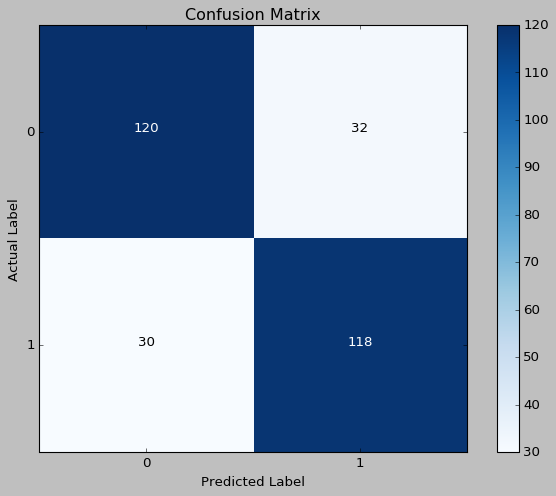

In [0]:
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'])

**Observation:** seems to have better results

## Try Count Vectorizer

{'wow': 979, 'loved': 387, 'place': 530, 'crust': 148, 'not': 438, 'good': 281, 'tasty': 806, 'texture': 818, 'nasty': 425, 'stopped': 764, 'late': 361, 'recommendation': 623, 'the': 822, 'selection': 689, 'menu': 408, 'great': 284, 'prices': 574, 'now': 440, 'getting': 274, 'want': 929, 'damn': 154, 'pho': 516, 'taste': 802, 'that': 821, 'fresh': 262, 'potatoes': 562, 'like': 369, 'tell': 811, 'time': 846, 'kept': 351, 'fries': 267, 'touch': 867, 'service': 697, 'prompt': 586, 'would': 977, 'cashier': 107, 'no': 436, 'care': 106, 'ended': 208, 'overpriced': 462, 'tried': 879, 'chicken': 117, 'mmmm': 415, 'pretty': 571, 'sure': 784, 'human': 329, 'hair': 296, 'highly': 313, 'recommended': 624, 'waitress': 924, 'little': 373, 'slow': 714, 'this': 838, 'worth': 976, 'let': 367, 'vegas': 911, 'food': 259, 'amazing': 16, 'cute': 153, 'beautiful': 60, 'so': 716, 'performed': 506, 'right': 634, 'red': 625, 'stuff': 766, 'they': 828, 'brought': 88, 'salad': 650, 'asked': 28, 'wall': 927, 'mex

,10,100,12,20,30,35,40,absolutely,acknowledged,actually,...,yellow,yellowtail,yelpers,you,your,yucky,yukon,yum,yummy,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Training starts...
Training ends...
Number of misclassifications: 63 (out of 300)
Error:  0.21

Confusion Matrix:
[[121  31]
 [ 32 116]]



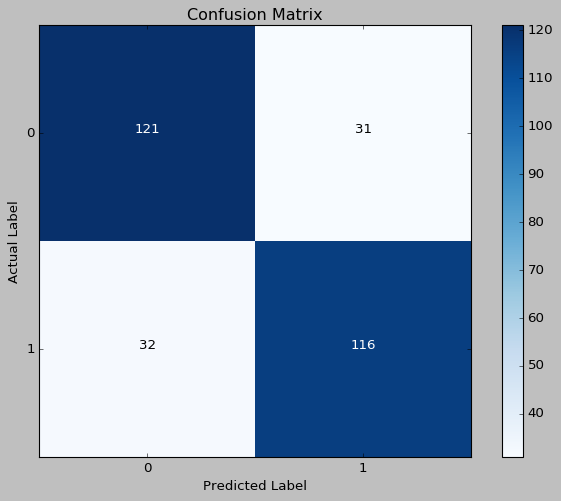

In [0]:
from sklearn.feature_extraction.text import CountVectorizer
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'], CountVectorizer(max_features=1000))

## Try tri-grams

{'not tasty texture': 152, 'rick steve recommendation': 642, 'selection menu great': 754, 'now getting angry': 168, 'potatoes like rubber': 457, 'rubber tell ahead': 665, 'no care ended': 70, 'tried cape cod': 909, 'ravoli chicken cranberry': 550, 'pretty sure human': 475, 'shocked no signs': 842, 'no signs indicate': 81, 'signs indicate cash': 862, 'this place not': 898, 'place not worth': 390, 'not worth time': 163, 'right red velvet': 645, 'red velvet cake': 589, 'velvet cake ohhh': 974, 'ohhh stuff good': 183, 'restaurant food luke': 617, 'our sever running': 237, 'sever running like': 835, 'running like totally': 674, 'place accident not': 358, 'quick place grab': 535, 'place grab bite': 372, 'pub food favor': 513, 'overall like place': 255, 'redeeming quality restaurant': 590, 'quality restaurant inexpensive': 530, 'portions good prices': 443, 'poor service waiter': 438, 'service waiter feel': 831, 'my visit hiro': 13, 'shrimp tender moist': 855, 'not deal good': 96, 'sides good 

,10 minutes re,food good service,food great service,going anytime soon,good things place,great food great,great place eat,my husband ate,my husband said,my order not,...,very poor service,very very disappointed,vibe letting eat,vinaigrette better overall,vinegrette baby greens,violinists playing songs,visit especially enjoyed,we wo going,will never ever,wo going anytime
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Training starts...
Training ends...
Number of misclassifications: 147 (out of 300)
Error:  0.49

Confusion Matrix:
[[  5 147]
 [  0 148]]



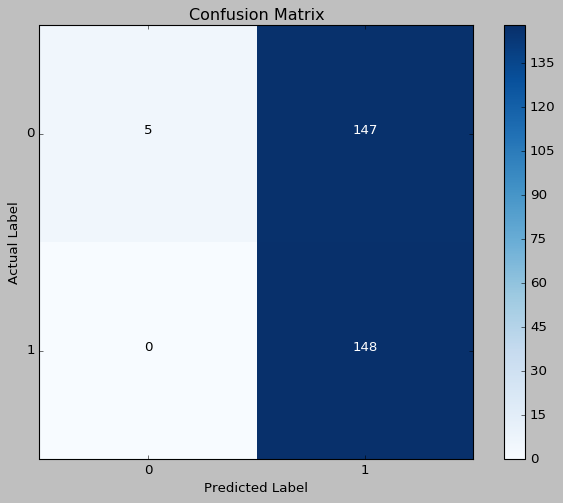

In [0]:
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'], CountVectorizer(max_features=1000, ngram_range=(3, 3)))

## Try bi-grams

{'wow loved': 970, 'loved place': 96, 'not good': 244, 'not tasty': 282, 'rick steve': 691, 'recommendation loved': 624, 'the selection': 860, 'now getting': 298, 'potatoes like': 470, 'rubber tell': 718, 'the fries': 854, 'would not': 968, 'the cashier': 850, 'no care': 191, 'ravoli chicken': 585, 'pretty sure': 496, 'no signs': 206, 'little slow': 93, 'slow service': 830, 'this place': 874, 'place not': 394, 'not worth': 292, 'not like': 256, 'the food': 853, 'food amazing': 41, 'right red': 695, 'red velvet': 630, 'ohhh stuff': 318, 'they brought': 869, 'salad asked': 742, 'friendly staff': 56, 'hour food': 80, 'restaurant food': 660, 'running like': 726, 'the worst': 868, 'worst salmon': 961, 'salmon sashimi': 756, 'found place': 54, 'not happier': 246, 'quick place': 564, 'pub food': 538, 'overall like': 334, 'like place': 92, 'place lot': 389, 'redeeming quality': 631, 'quality restaurant': 557, 'restaurant inexpensive': 662, 'portions good': 456, 'good prices': 61, 'poor service

,10 minutes,20 minutes,30 min,30 minutes,35 minutes,40 minutes,absolutely amazing,absolutely no,anytime soon,as service,...,you wo,your servers,your staff,yukon gold,yum sauce,yum yum,yummy christmas,yummy try,yummy tummy,zero stars
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Training starts...
Training ends...
Number of misclassifications: 115 (out of 300)
Error:  0.38333333333333336

Confusion Matrix:
[[ 44 108]
 [  7 141]]



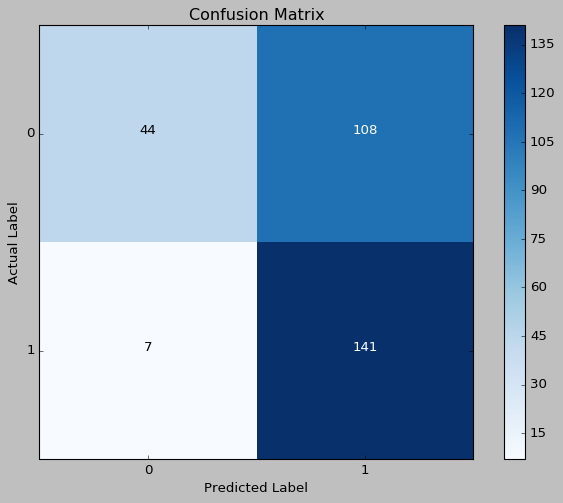

In [0]:
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'], CountVectorizer(max_features=1000, ngram_range=(2, 2)))

**Observation:** tf-idf seems to be performing the best

## Try lowercasing as a part of pre-processing (as our best model isn't using Lemma/Stem) 

In [0]:
def process_and_tokenize(str, word_base):  
  str = str.lower()
  tokens = []
  whitepaces = []
  doc = nlp(str)
  for t in doc:
    if not (t.is_stop and t.text not in STOP_WORDS_EXLUSION) and not t.is_punct:      
      tokens.append(t.text if word_base==Wordbase.TEXT else t.lemma_)
      whitepaces.append(t.whitespace_ if len(t.whitespace_)>0 else ' ')
  
  ret = np.nan
  if len(tokens)>0:
    ret = tokens[0]
    for i in range(1, len(tokens)):
      ret = whitepaces[i - 1].join((ret, tokens[i]))
  
  return ret

In [0]:
df['Processed Review'] = df['Review'].apply(lambda str: process_and_tokenize(str, Wordbase.TEXT))
df.head()

,Review,Liked,Processed Review
0,Wow... Loved this place.,1,wow loved place
1,Crust is not good.,0,crust not good
2,Not tasty and the texture was just nasty.,0,not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,stopped late bank holiday rick steve recommend...
4,The selection on the menu was great and so wer...,1,selection menu great prices


In [0]:
print(df.isnull().sum())

Review              0
Liked               0
Processed Review    2
dtype: int64


In [0]:
df_cleaned = df.dropna()
print(df_cleaned.shape)
print(df_cleaned.isnull().sum())

(998, 3)
Review              0
Liked               0
Processed Review    0
dtype: int64


{'wow': 673, 'loved': 352, 'place': 443, 'crust': 131, 'not': 399, 'good': 255, 'tasty': 597, 'texture': 602, 'nasty': 387, 'stopped': 571, 'late': 327, 'recommendation': 486, 'selection': 523, 'menu': 372, 'great': 258, 'prices': 464, 'getting': 249, 'want': 650, 'damn': 136, 'pho': 437, 'taste': 594, 'fresh': 237, 'potatoes': 458, 'like': 334, 'tell': 599, 'time': 610, 'kept': 317, 'fries': 242, 'touch': 620, 'service': 531, 'cashier': 92, 'no': 397, 'care': 91, 'ended': 189, 'overpriced': 417, 'tried': 624, 'chicken': 102, 'mmmm': 379, 'pretty': 461, 'sure': 584, 'human': 299, 'hair': 270, 'highly': 285, 'recommended': 487, 'waitress': 647, 'little': 338, 'slow': 545, 'worth': 672, 'let': 332, 'vegas': 637, 'food': 235, 'amazing': 12, 'cute': 135, 'beautiful': 50, 'right': 497, 'red': 488, 'stuff': 573, 'brought': 77, 'salad': 506, 'asked': 20, 'wall': 649, 'mexican': 373, 'tacos': 590, 'friendly': 240, 'staff': 555, 'took': 616, 'hour': 295, 'tables': 588, 'restaurant': 491, 'warm'

,10,100,12,20,30,35,40,absolutely,acknowledged,actually,...,worse,worst,worth,wow,wrap,wrong,year,years,yummy,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.713538,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0



Training starts...
Training ends...
Number of misclassifications: 69 (out of 300)
Error:  0.23

Confusion Matrix:
[[121  43]
 [ 26 110]]



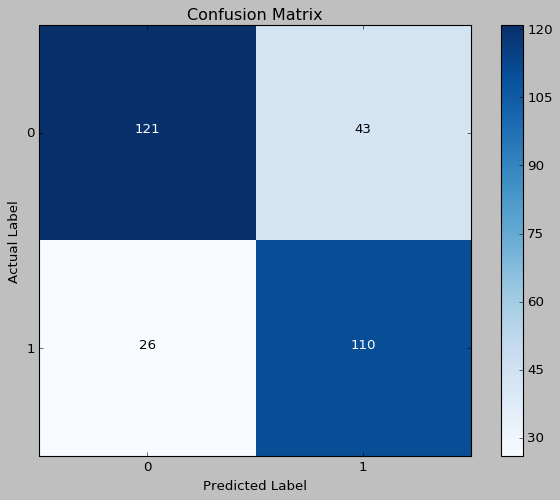

In [0]:
classify_and_plot_confusion_matrix(df_cleaned['Processed Review'], df_cleaned['Liked'])

**Observation:** didn't help

***
## Best performing model (uptil now) – NLTK + custom_stop_words + Lemma

In [0]:
def process_and_tokenize(str, word_base):
  stopwords = stop_word_list()
  lemmatizer = WordNetLemmatizer()
  stemmer = PorterStemmer()
  
  tokens = []
  for t in word_tokenize(str):
    updated_t = remove_punctuation(t)
    if len(updated_t)>0 and t.lower() not in stopwords:
      if (word_base==Wordbase.LEMMA):
        tokens.append(lemmatizer.lemmatize(updated_t, pos_for_WordNetLemmatizer(updated_t)))
      else:
        tokens.append(stemmer.stem(updated_t))
  
  return ' '.join(tokens)

In [0]:
df['Processed Review'] = df['Review'].apply(lambda str: process_and_tokenize(str, Wordbase.LEMMA))
df.head()

,Review,Liked,Processed Review
0,Wow... Loved this place.,1,Wow Loved place
1,Crust is not good.,0,Crust not good
2,Not tasty and the texture was just nasty.,0,Not tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,Stopped late May bank holiday Rick Steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great price


{'wow': 695, 'loved': 365, 'place': 465, 'crust': 148, 'not': 418, 'good': 270, 'tasty': 616, 'texture': 622, 'nasty': 407, 'stopped': 594, 'late': 342, 'may': 378, 'recommendation': 512, 'love': 364, 'selection': 544, 'menu': 387, 'great': 272, 'price': 482, 'get': 265, 'want': 671, 'damn': 153, 'pho': 459, 'nt': 421, 'taste': 614, 'fresh': 255, 'potato': 478, 'like': 351, 'could': 139, 'tell': 618, 'make': 371, 'time': 632, 'kept': 334, 'fry': 260, 'touch': 641, 'service': 549, 'would': 694, 'go': 268, 'back': 44, 'cashier': 103, 'no': 416, 'care': 102, 'ever': 214, 'say': 536, 'still': 590, 'end': 205, 'overprice': 438, 'try': 646, 'chicken': 114, 'mmmm': 395, 'disgust': 180, 'pretty': 481, 'sure': 605, 'human': 313, 'hair': 283, 'sign': 557, 'highly': 300, 'recommend': 511, 'waitress': 668, 'little': 354, 'slow': 566, 'worth': 693, 'let': 348, 'vegas': 658, 'food': 253, 'amaze': 16, 'also': 13, 'cute': 152, 'beautiful': 58, 'right': 520, 'the': 624, 'red': 513, 'cake': 99, 'stuff':

,10,100,12,20,30,35,40,absolutely,acknowledge,actually,...,worst,worth,would,wow,wrap,wrong,year,yet,yummy,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.677896,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0



Training starts...
Training ends...
Number of misclassifications: 61 (out of 300)
Error:  0.20333333333333334

Confusion Matrix:
[[124  28]
 [ 33 115]]



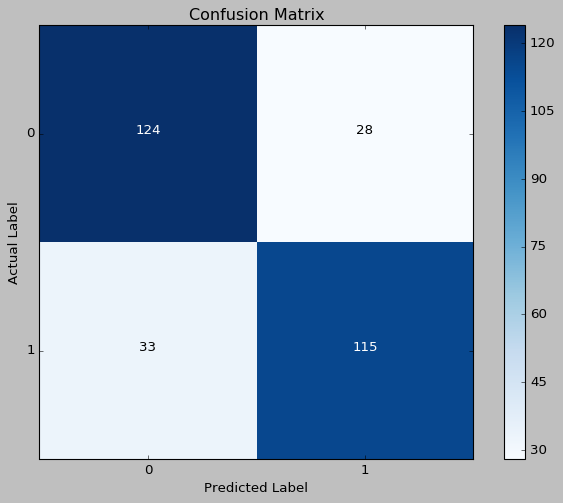

In [0]:
classify_and_plot_confusion_matrix(df['Processed Review'], df['Liked'])